- `Acesso aos dados`: [Sentinel-5P NRTI CO: Near Real-Time Carbon Monoxide](https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S5P_NRTI_L3_CO)
- `Período dos dados`: 2018-11-22T12:00:13Z à 2024-05-18T09:01:55Z
- `Resolução espacial`: 1113.2 metros
- `Resolução temporal`: diária
- `Código realizado por`: Enrique V. Mattos - 19/05/2024

# **1° Passo:** Preparando ambiente

In [1]:
# instalando bibliotecas
!pip install -q ultraplot cartopy salem rasterio

# importa bibliotecas
import numpy as np
import ultraplot as uplt
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import time
from zipfile import ZipFile
import salem
from datetime import datetime
import glob
import xarray as xr
import os
import cartopy.crs as ccrs
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# monta drive
from google.colab import drive
drive.mount('/content/drive')

# caminho do drive
dir = '/content/drive/MyDrive/5_EXTENSAO/02_prefeitura_analise_periodo_chuvoso_2024_2025'

# leitura do shapefile do Brasil
shapefile_brasil = salem.read_shapefile('https://github.com/evmpython/shapefile/raw/main/brasil/BRAZIL.shp')

# url dos shapefiles
url = 'https://github.com/evmpython/shapefile/raw/main/'

# leitura do shapefile com a biblioteca SALEM
shp = salem.read_shapefile(f'{url}itajuba/itajuba.shp')
itajuba = salem.read_shapefile(f'{url}itajuba/itajuba.shp')
mg = salem.read_shapefile(f'{url}estado_MG/MG_UF_2019.shp')

# limites do Brasil
lonmin, lonmax, latmin, latmax = -75.0, -33.0, -35.0, 7.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.9 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/ultraplot/__init__.py:77: UltraPlotWarning: Rebuilding font cache. This usually happens after installing or updating ultraplot.
  register_fonts(default=True)


Mounted at /content/drive


# **PARTE 1):** Processamento

## 1) Preparando ambiente

In [2]:
# instalando eemont e wxee
!pip install -q eemont #wxee

# importando GEE e geemap
import ee, geemap, eemont#, wxee

# inicializando GEE
geemap.ee_initialize(project='ee-enrique')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.7/134.7 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.7/224.7 kB 8.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


## 2) Mapa no GEE

In [3]:
#========================================================================================================================#
#                                          FILTRA REGIÃO DE INTERESSE
#========================================================================================================================#
brasil = ee.FeatureCollection('FAO/GAUL/2015/level0').filter(ee.Filter.eq('ADM0_NAME', 'Brazil'))
estado_mg = ee.FeatureCollection('FAO/GAUL/2015/level1').filter(ee.Filter.eq('ADM1_NAME', 'Minas Gerais'))
municipio_itajuba = ee.FeatureCollection('FAO/GAUL/2015/level2').filter(ee.Filter.eq('ADM2_NAME', 'Itajuba'))

#========================================================================================================================#
#                                            CARREGA OS DADOS
#========================================================================================================================#
# carrega os dados. CO_column_number_density esta em unidades de "mol/m^2"
S5P_co = ee.ImageCollection('COPERNICUS/S5P/NRTI/L3_CO') \
           .filter(ee.Filter.date('2025-02-01', '2025-03-01')) \
           .select('CO_column_number_density') \
           .filterBounds(estado_mg)

#========================================================================================================================#
#                                           PLOTA FIGURA
#========================================================================================================================#
# cria a moldura do mapa
Map = geemap.Map()

# centraliza o mapa na região
Map.centerObject(estado_mg)

# parâmetros de visualização
vis = {'min': 0, 'max': 150, 'palette': ['black', 'blue', 'purple', 'cyan', 'green', 'yellow', 'red']}

# plota mapa
Map.addLayer(S5P_co.mean().clip(estado_mg).multiply(2241.15), vis, 'Mapa de CO')

# contorno da região
style1 = {'color': 'red', 'fillColor': '00000000'}
Map.addLayer(estado_mg.style(**style1), {}, 'MG')

# barra de cores
Map.add_colorbar_branca(colors=vis['palette'], vmin=vis['min'], vmax=vis['max'], layer_name='CO (DU)')

# exibe na tela
Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

## 3) Produz série temporal

In [14]:
%%time
#========================================================================================================================#
#                                            FILTRA REGIÃO DE INTERESSE
#========================================================================================================================#
brasil = ee.FeatureCollection('FAO/GAUL/2015/level0').filter(ee.Filter.eq('ADM0_NAME', 'Brazil'))
estado_mg = ee.FeatureCollection('FAO/GAUL/2015/level1').filter(ee.Filter.eq('ADM1_NAME', 'Minas Gerais'))
municipio_itajuba = ee.FeatureCollection('FAO/GAUL/2015/level2').filter(ee.Filter.eq('ADM2_NAME', 'Itajuba'))

#========================================================================================================================#
#                                            DEFINE A DATA INICIAL E FINAL
#========================================================================================================================#
# data INICIAL
anoi, mesi, diai = 2019, 1,  1

# data FINAL
anof, mesf, diaf = 2025, 4, 30

#========================================================================================================================#
#                                                  CARREGA OS DADOS
#========================================================================================================================#
# DATA FINAL: ajusta a data final. Soma 1 dia na data final
datetime = datetime.strptime(f'{str(anof)}-{str(mesf).zfill(2)}-{str(diaf).zfill(2)}', '%Y-%m-%d')
data_final = str(datetime + timedelta(days=1))[0:10] # 2024-04-01

# DATA INICIAL
data_inicial = f'{anoi}-{str(mesi).zfill(2)}-{str(diai).zfill(2)}'

print('PROCESSANDO')
print('#==========================================================================#')
print('DATA INICIAL:', data_inicial)
print('DATA FINAL:', data_final)
print('#==========================================================================#')

# carrega os dados
S5P_co = ee.ImageCollection('COPERNICUS/S5P/NRTI/L3_CO') \
           .filter(ee.Filter.date(data_inicial, data_final)) \
           .select('CO_column_number_density') \
           .filterBounds(municipio_itajuba)

#========================================================================================================================#
#                                              PRODUZ SÉRIE TEMPORAL
#========================================================================================================================#
# gera a serie temporal
S5P_co_ts = S5P_co.getTimeSeriesByRegion(geometry = municipio_itajuba,
                                         bands = 'CO_column_number_density',
                                         reducer = ee.Reducer.max(),
                                         scale = 1000) # scale de 1000metros (Wall time: 21.5 s) e 10_000 metros (Wall time: 26.3 s)

# inserindo os dados numa tabela
S5P_co_ts = geemap.ee_to_df(S5P_co_ts)

# transformando -9999.0 em NaN
S5P_co_ts[S5P_co_ts == -9999] = np.nan

# eliminando os dados NaN
S5P_co_ts = S5P_co_ts.dropna()

# transforma de mol/m^2	 para DU
S5P_co_ts['CO_column_number_density'] = S5P_co_ts['CO_column_number_density']*2241.15

# transformando para DateTime
S5P_co_ts['date'] = pd.to_datetime(S5P_co_ts['date'], infer_datetime_format = True)

# transformando a coluna de datas('date') no índice do DataFrame
S5P_co_ts.index = S5P_co_ts['date']

# remove colunas
S5P_co_ts.drop(['reducer', 'date'], inplace=True, axis=1)

# salva num arquivo CSV
S5P_co_ts.to_csv(f'{dir}/output/02_MONOXIDO_CARBONO/tabela_S5P_co_diaria.csv')

# mostra a tabela
#S5P_co_ts

#========================================================================================================================#
#                                                 AGRUPA POR MÊS
#========================================================================================================================#
# agrupa os dados por mês
df_mes = S5P_co_ts.groupby(pd.Grouper(freq='1M')).max()['CO_column_number_density']

# preenche com zeros os meses de 2025 que ainda não chegaram
ano_mes_dia = []

ano_mesi, ano_mesf = '20190101', '20251231'
for data in pd.date_range(ano_mesi, ano_mesf, freq='1M'):
    ano_mes_dia.append(data.strftime('%Y-%m-%d'))

datas = np.array(ano_mes_dia)

df_mes = df_mes.reindex(datas, fill_value=np.nan)

# mostra os dados
display(df_mes)

PROCESSANDO
#==========================================================================#
DATA INICIAL: 2019-01-01
DATA FINAL: 2025-05-01
#==========================================================================#


,CO_column_number_density
date,
2019-01-31,76.163312
2019-02-28,80.330107
2019-03-31,90.450376
2019-04-30,82.802644
2019-05-31,83.043126
...,...
2025-08-31,NaN
2025-09-30,NaN
2025-10-31,NaN


CPU times: user 177 ms, sys: 12.2 ms, total: 190 ms
Wall time: 22.5 s


In [15]:
S5P_co_ts

,CO_column_number_density
date,
2019-01-01 15:58:44,59.808656
2019-01-02 17:18:44,73.871546
2019-01-06 16:03:45,59.700479
2019-01-07 17:23:45,60.505049
2019-01-09 16:48:44,60.435978
...,...
2025-04-08 17:21:30,52.051790
2025-04-09 17:01:30,59.828960
2025-04-10 16:41:30,49.012427


In [16]:
#S5P_co

In [19]:
# matriz com formato de anos x meses
S5P_co_table = np.reshape(df_mes.values, ((anof - anoi) + 1, 12), order='C')
S5P_co_table

array([[ 76.16331226,  80.33010677,  90.45037608,  82.80264367,
         83.04312638,  74.40315652,  79.24638169,  87.62878692,
        125.54449546, 104.958695  , 101.85942029,  77.6574292 ],
       [ 75.33021385,  77.57776367,  79.42980778,  87.14583446,
        113.36038398,  81.3846695 ,  89.95785574,  86.67683308,
        129.74844272, 163.37257147,  92.19950527,  87.39773016],
       [121.78428571,  82.17279172,  73.77311254,  78.78461883,
         95.13182394, 102.13568653,  72.465271  , 100.12092169,
        116.26407885, 113.4044436 , 146.42328345,  73.55931534],
       [ 79.91602519,  81.58857504, 105.6750951 ,  73.24525117,
         99.58140855,  70.75500617,  81.73066709,  76.04957683,
        141.66844697, 108.63705431,  84.6880024 ,  78.25887808],
       [ 65.37700671,  78.65364075,  82.7432744 ,  61.80223097,
         71.24646619,  65.1187251 ,  72.48237781,  92.69345087,
        104.12566338, 137.27090771, 132.36452902,  86.46369313],
       [ 76.21661318,  79.82995881,

# **PARTE 2):** Plota figura

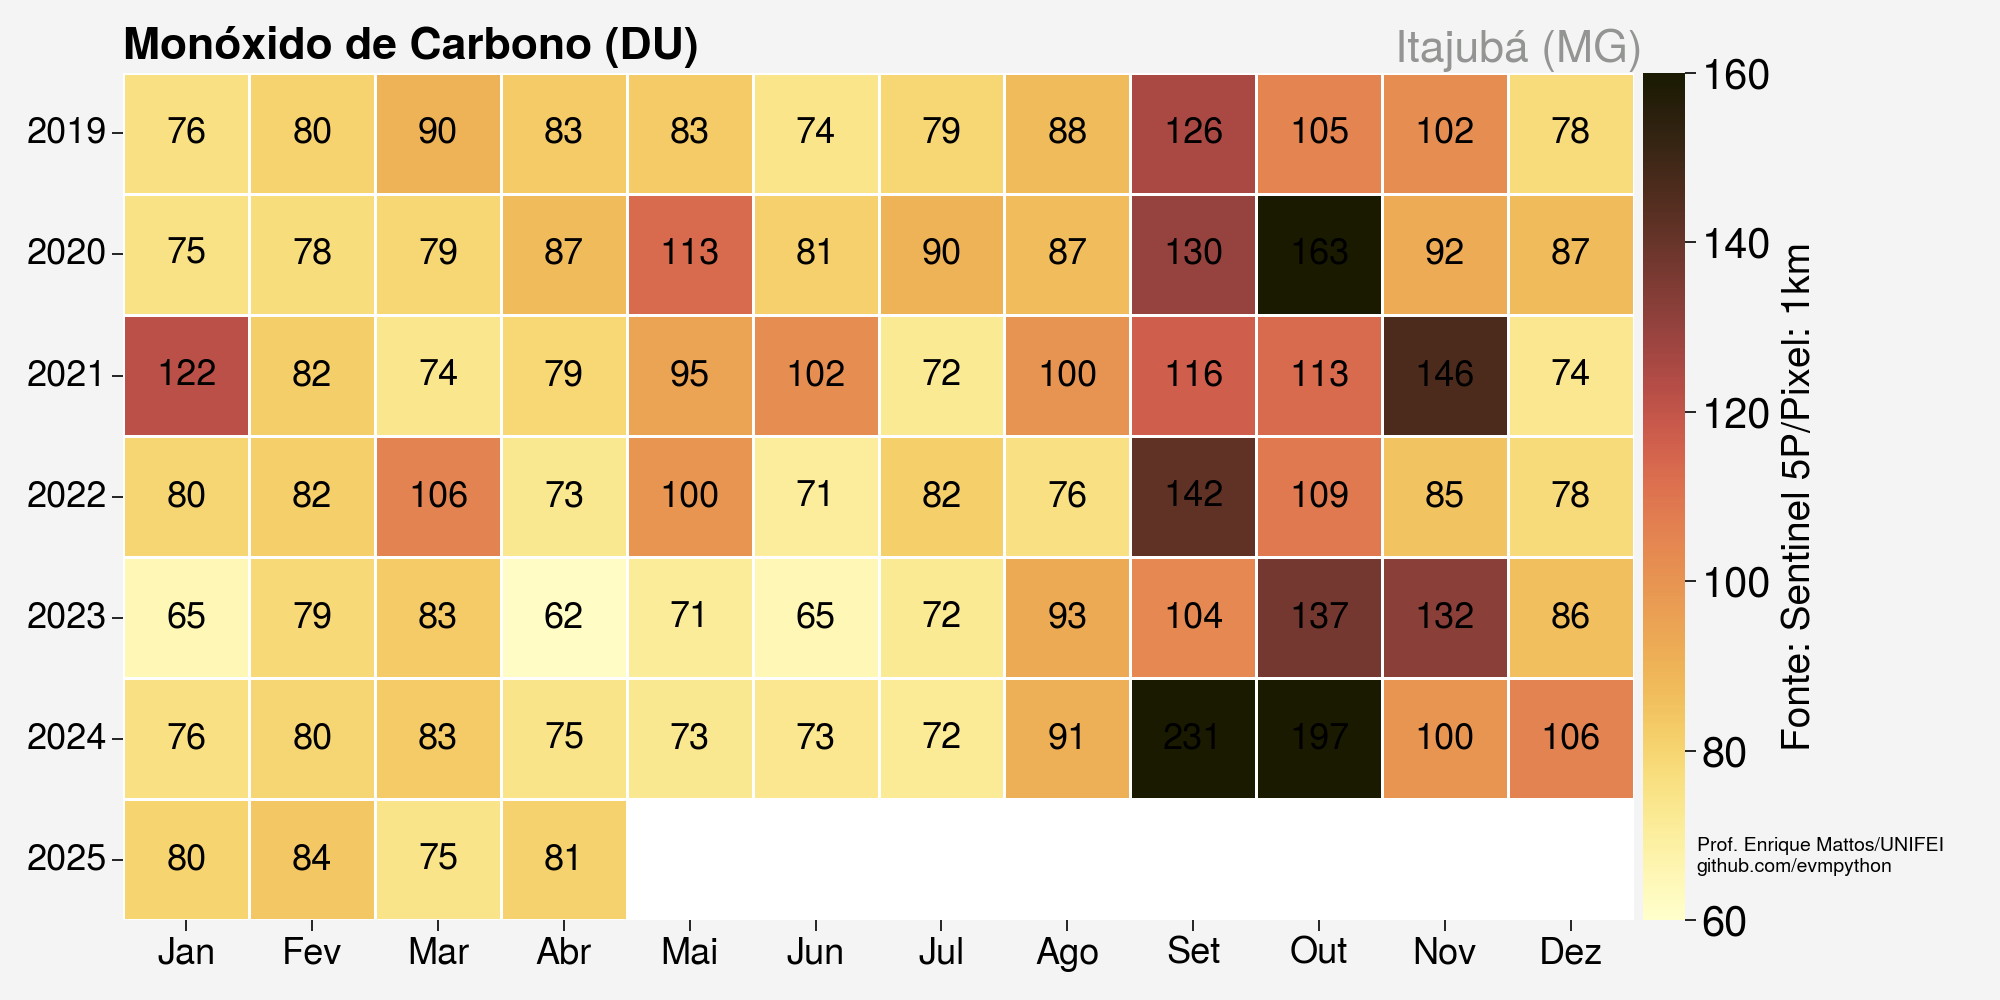

CPU times: user 1.24 s, sys: 529 ms, total: 1.76 s
Wall time: 1.3 s


In [25]:
%%time
#========================================================#
#               DEFINIÇÕES INICIAIS
#========================================================#
# moldura da figura
fig, ax = plt.subplots(figsize=(10,5))

# criando heatmap com seaborn
# opções de palltes: https://proplot.readthedocs.io/en/latest/colormaps.html
sns.heatmap(S5P_co_table,
            vmin=60, vmax=160,
            cmap='lajolla',
            xticklabels=['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'],
            yticklabels=uplt.arange(anoi, anof, 1),
            linewidth=0.5,
            linecolor='white',
            cbar_kws={'label': ' ',
                      'shrink': 1.0,
                      'pad': 0.005,
                      'orientation': 'vertical'},
            annot=True, fmt=".0f",
            annot_kws={'color': 'black',
                       'fontsize': 13,
                       'fontweight': 'medium'})

# configurações da barra de cores
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=15, axis="both")
cbar.set_label('Fonte: Sentinel 5P/Pixel: 1km', fontsize=14)
cbar.ax.minorticks_off()

# título
ax.set_title('Monóxido de Carbono (DU)', fontsize=16, color='black', fontweight='bold', loc='left')
ax.text(10.1, -0.092, 'Itajubá (MG)', color='grey', fontsize=16, zorder=5)

# retirar os minorticks
ax.minorticks_off()
plt.grid(False) # Corrected line to turn off the grid

# orientações labels do eixo Y
plt.yticks(rotation=0, fontsize=13)
plt.xticks(rotation=0, fontsize=13)

# informação na figura
ax.text(12.5, 6.6, 'Prof. Enrique Mattos/UNIFEI\ngithub.com/evmpython', fontsize=7, color='black', zorder=5)

# salva figura
plt.tight_layout()
plt.savefig(f'{dir}/output/Fig_3_S5P_co_table_ano_mes_ITAJUBA_2025-04-12_1km_diario.jpg', bbox_inches='tight', dpi=300)
plt.show()